In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import json

device = torch.device('cpu')

# Load test data
data = np.load('data/processed_data.npz')
X_test = torch.FloatTensor(data['X_test'])
y_test = torch.LongTensor(data['y_test'])
snr_test = data['snr_test']

test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)

with open('data/label_mapping.json', 'r') as f:
    mod_to_label = json.load(f)

print(f"Test samples: {len(X_test)}")
print(f"SNR range: {snr_test.min()} to {snr_test.max()} dB")

Test samples: 44000
SNR range: -20 to 18 dB


In [2]:
# Define model architectures (same as training)
class CNN1D(nn.Module):
    def __init__(self):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=8, padding='same')
        self.conv2 = nn.Conv1d(64, 64, kernel_size=8, padding='same')
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 32, 128)
        self.fc2 = nn.Linear(128, 11)
        
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(2, 64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, 11)
        
    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=8, padding='same')
        self.pool = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(64, 64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, 11)
        
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

# Load models
cnn = CNN1D()
cnn.load_state_dict(torch.load('models/cnn_model.pt', map_location=device))
cnn.eval()

lstm = LSTMModel()
lstm.load_state_dict(torch.load('models/lstm_model.pt', map_location=device))
lstm.eval()

hybrid = HybridModel()
hybrid.load_state_dict(torch.load('models/hybrid_model.pt', map_location=device))
hybrid.eval()

print("All models loaded.")

All models loaded.


In [3]:
def evaluate_model(model, test_loader, snr_test):
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).argmax(1).numpy()
            all_preds.extend(preds)
    
    all_preds = np.array(all_preds)
    all_labels = y_test.numpy()
    
    # Per-SNR accuracy
    snr_values = sorted(list(set(snr_test)))
    snr_accs = []
    for snr in snr_values:
        mask = snr_test == snr
        acc = (all_preds[mask] == all_labels[mask]).mean()
        snr_accs.append(acc)
    
    overall_acc = (all_preds == all_labels).mean()
    return snr_values, snr_accs, overall_acc

# Evaluate all models
snr_vals, cnn_accs, cnn_overall = evaluate_model(cnn, test_loader, snr_test)
_, lstm_accs, lstm_overall = evaluate_model(lstm, test_loader, snr_test)
_, hybrid_accs, hybrid_overall = evaluate_model(hybrid, test_loader, snr_test)

print(f"Overall Accuracy:")
print(f"  CNN:    {cnn_overall:.4f} ({cnn_overall*100:.1f}%)")
print(f"  LSTM:   {lstm_overall:.4f} ({lstm_overall*100:.1f}%)")
print(f"  Hybrid: {hybrid_overall:.4f} ({hybrid_overall*100:.1f}%)")

C:\Users\nabee\anaconda3\envs\amc\lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv1d(


Overall Accuracy:
  CNN:    0.4975 (49.8%)
  LSTM:   0.1112 (11.1%)
  Hybrid: 0.2114 (21.1%)


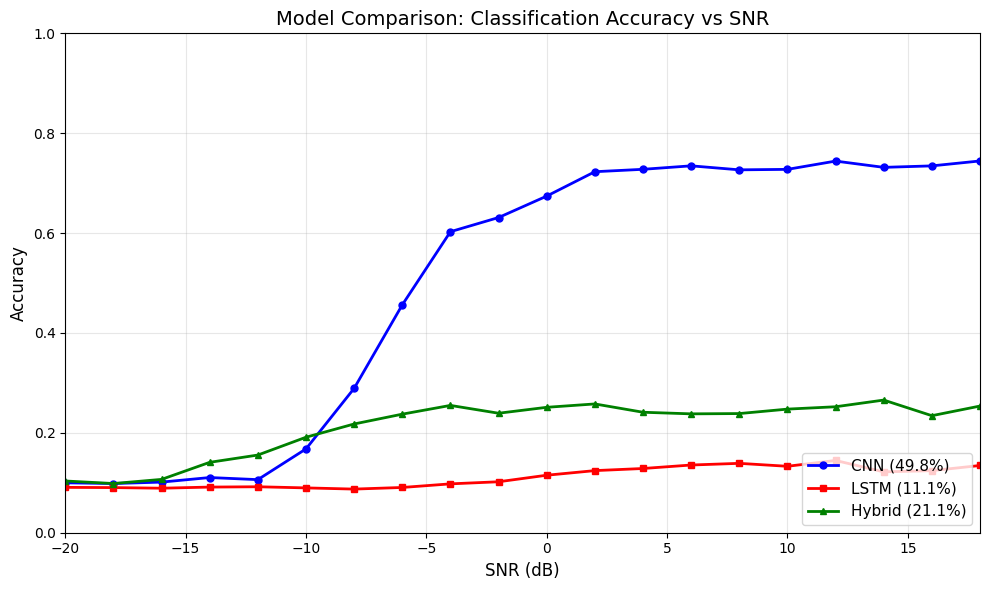

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(snr_vals, cnn_accs, 'b-o', label=f'CNN ({cnn_overall*100:.1f}%)', linewidth=2, markersize=5)
plt.plot(snr_vals, lstm_accs, 'r-s', label=f'LSTM ({lstm_overall*100:.1f}%)', linewidth=2, markersize=5)
plt.plot(snr_vals, hybrid_accs, 'g-^', label=f'Hybrid ({hybrid_overall*100:.1f}%)', linewidth=2, markersize=5)

plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison: Classification Accuracy vs SNR', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.xlim([-20, 18])

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()

In [5]:
# Summary table
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<12} {'Overall':>10} {'High SNR (≥0dB)':>18} {'Low SNR (<0dB)':>18}")
print("-" * 60)

for name, accs, overall in [('CNN', cnn_accs, cnn_overall), 
                             ('LSTM', lstm_accs, lstm_overall), 
                             ('Hybrid', hybrid_accs, hybrid_overall)]:
    high_snr = np.mean([a for s, a in zip(snr_vals, accs) if s >= 0])
    low_snr = np.mean([a for s, a in zip(snr_vals, accs) if s < 0])
    print(f"{name:<12} {overall*100:>9.1f}% {high_snr*100:>17.1f}% {low_snr*100:>17.1f}%")

print("=" * 60)

MODEL COMPARISON SUMMARY
Model           Overall    High SNR (≥0dB)     Low SNR (<0dB)
------------------------------------------------------------
CNN               49.8%              72.7%              26.6%
LSTM              11.1%              13.0%               9.2%
Hybrid            21.1%              24.8%              17.5%


In [6]:
# Save results to JSON
results = {
    'cnn': {'overall': float(cnn_overall), 'per_snr': {str(s): float(a) for s, a in zip(snr_vals, cnn_accs)}},
    'lstm': {'overall': float(lstm_overall), 'per_snr': {str(s): float(a) for s, a in zip(snr_vals, lstm_accs)}},
    'hybrid': {'overall': float(hybrid_overall), 'per_snr': {str(s): float(a) for s, a in zip(snr_vals, hybrid_accs)}}
}

with open('results/model_comparison.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to results/model_comparison.json")

Results saved to results/model_comparison.json
